In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression



In [10]:
# Load the three datasets, using the first column (patient id) as the index
datasets = {}
for name in ["metadata", "microbiome", "metabolome"]:
    df = pd.read_csv(f"train/{name}.csv")
    df = df.rename(columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")
    datasets[name] = df
    print(f"{name:11s} -> {df.shape[0]} rows (patients), {df.shape[1]} features")

metadata    -> 1738 rows (patients), 5 features
microbiome  -> 1738 rows (patients), 170 features
metabolome  -> 1738 rows (patients), 102 features


## 1. Mutual Information matrix: Microbiome vs Microbiome

microbiome samples used: 1390 | taxa: 170
microbiome x microbiome MI shape: (170, 170)


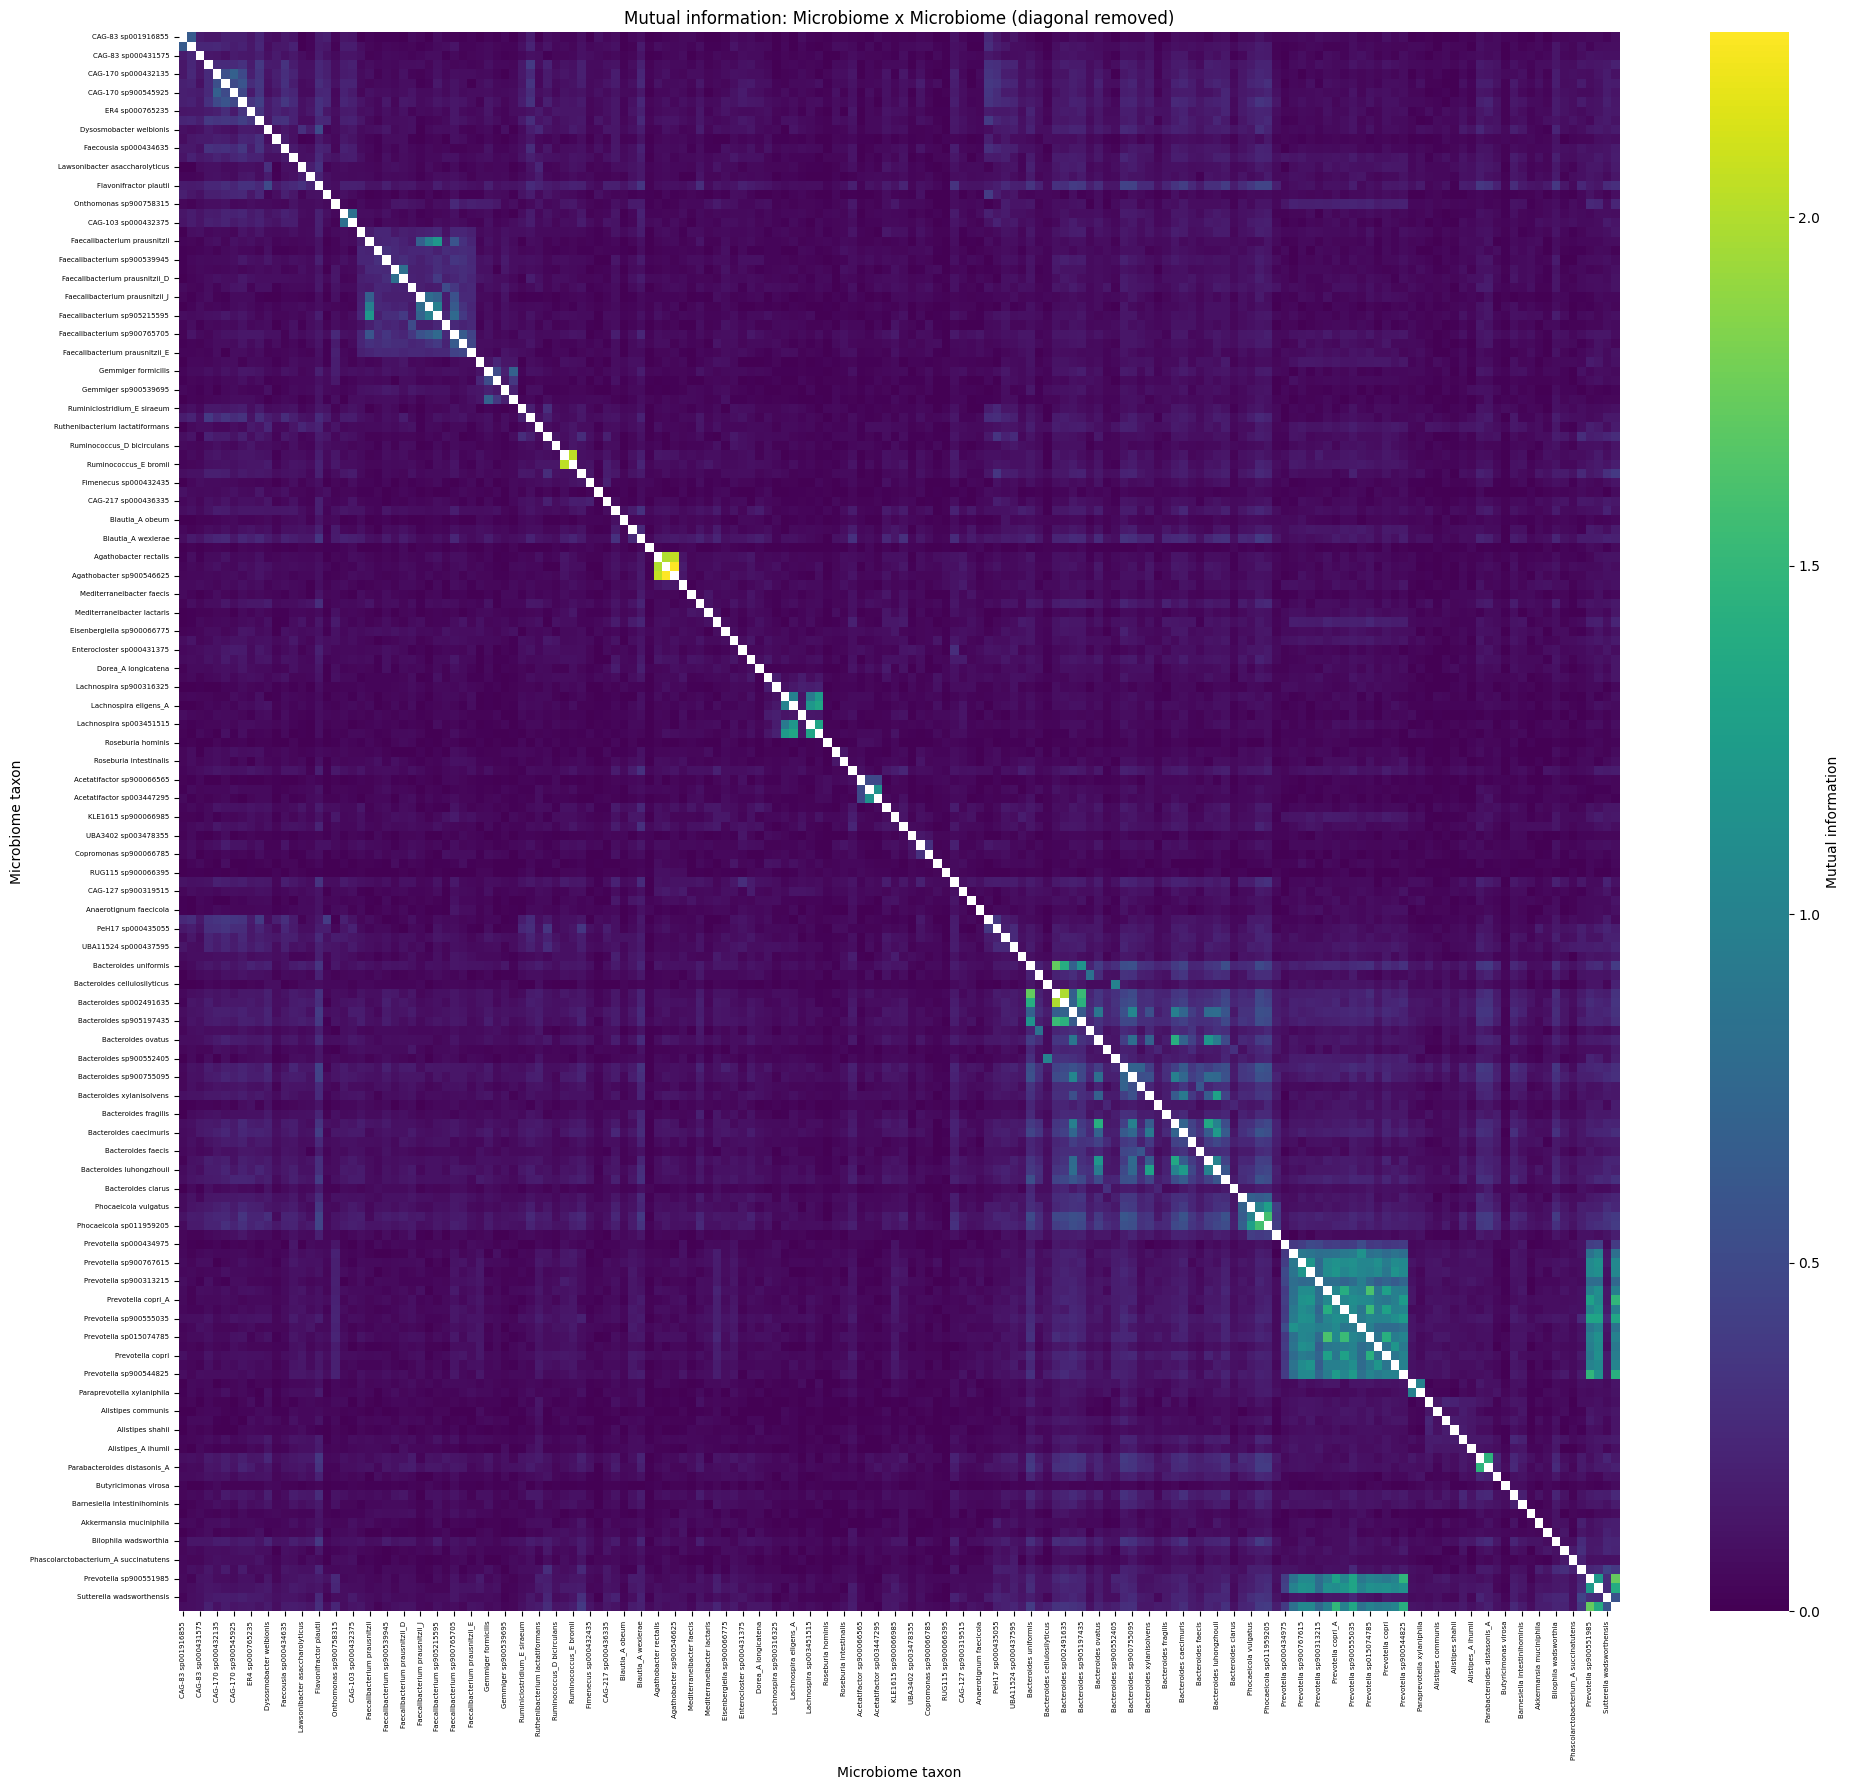

In [11]:
def mi_matrix_between(rows_df, cols_df, random_state=0):
    """MI matrix where entry [i, j] = MI(rows_df[i], cols_df[j]).

    Both inputs are standardized independently before estimation.
    """
    rows_scaled = StandardScaler().fit_transform(rows_df)
    cols_scaled = StandardScaler().fit_transform(cols_df)
    out = pd.DataFrame(index=rows_df.columns, columns=cols_df.columns, dtype=float)
    for i, name in enumerate(rows_df.columns):
        out.loc[name] = mutual_info_regression(
            cols_scaled, rows_scaled[:, i], random_state=random_state)
    return out

# Reload each dataset independently and keep its OWN non-empty rows
# (drops that dataset's 348 fully-empty patients -> ~1390 samples each).
# Note: section 8 reduced `micro`/`metab` to the 1042-sample intersection, so we
# reload here to use each dataset's full relevant data.
micro_clean = (pd.read_csv("train/microbiome.csv")
               .rename(columns={"Unnamed: 0": "SampleID"})
               .set_index("SampleID").dropna(how="all"))
print(f"microbiome samples used: {len(micro_clean)} | taxa: {micro_clean.shape[1]}")

# Microbiome is compositional -> CLR transform before MI; metabolome left as-is
micro_clean_clr = clr_transform(micro_clean)

# Within-dataset MI matrices (symmetric; diagonal = self-information, set to NaN)
mi_micro = mi_matrix_between(micro_clean_clr, micro_clean_clr)
for mat in (mi_micro,):
    for k in range(len(mat)):
        mat.iat[k, k] = np.nan

print("microbiome x microbiome MI shape:", mi_micro.shape)

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(mi_micro.astype(float), cmap="viridis",
            cbar_kws={"label": "Mutual information"}, ax=ax)
ax.set_title("Mutual information: Microbiome x Microbiome (diagonal removed)")
ax.set_xlabel("Microbiome taxon")
ax.set_ylabel("Microbiome taxon")
plt.xticks(fontsize=5, rotation=90)
plt.yticks(fontsize=5)
plt.tight_layout()
plt.show()



## 3. Microbiome composition: disease groups vs healthy control (group 8)

In [12]:
# --- 12.0 Cohort setup: France only, group 8 = control ------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu, kruskal, false_discovery_control
from skbio.stats.distance import DistanceMatrix, permanova, permdisp
from skbio.stats.ordination import pcoa
from sklearn.decomposition import PCA

_meta = pd.read_csv("train/metadata.csv").rename(
    columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")
_micro = pd.read_csv("train/microbiome.csv").rename(
    columns={"Unnamed: 0": "patient_id"}).set_index("patient_id")

# France patients that also have a complete microbiome row
_france = _meta.index[_meta["CENTER_C"] == "France"]
_complete = _micro.index[_micro.notna().all(axis=1)]
cohort_ids = _france.intersection(_complete)

abund = _micro.loc[cohort_ids].astype(float)
abund = abund.div(abund.sum(axis=1), axis=0)          # re-close so each row sums to 1
groups = _meta.loc[cohort_ids, "PATGROUPFINAL_C"].astype(str)

CONTROL = "8"
DISEASE = ["1", "2a", "2b", "3", "4", "5", "6", "7"]
GROUP_ORDER = DISEASE + [CONTROL]
GROUP_LABELS = {
    "1": "Metabolic syndrome", "2a": "Severe obesity",
    "2b": "Severe obesity (bariatric)", "3": "Type 2 diabetes",
    "4": "Cardiac group 4", "5": "Cardiac group 5", "6": "Cardiac group 6",
    "7": "Cardiac group 7", "8": "Control (lean)",
}


def clr_transform(df, pseudocount=None):
    """Centered log-ratio transform; zeros -> half the smallest non-zero value."""
    X = df.to_numpy(dtype=float)
    if pseudocount is None:
        pseudocount = X[X > 0].min() / 2.0
    X = np.where(X <= 0, pseudocount, X)
    log_X = np.log(X)
    return pd.DataFrame(log_X - log_X.mean(axis=1, keepdims=True),
                        index=df.index, columns=df.columns)


# Prevalence filter (safeguard against near-empty taxa). This dense table keeps all 170.
prevalence = (abund > 0).mean(axis=0)
taxa_keep = prevalence[prevalence >= 0.10].index
abund_f = abund[taxa_keep]
clr = clr_transform(abund_f)

print(f"France cohort with complete microbiome: n = {len(cohort_ids)}")
print(f"Taxa retained at >=10% prevalence: {len(taxa_keep)} / {abund.shape[1]}")
groups.value_counts().reindex(GROUP_ORDER).rename("n").to_frame()

France cohort with complete microbiome: n = 604
Taxa retained at >=10% prevalence: 170 / 170


,n
PATGROUPFINAL_C,
1,73
2a,90
2b,30
3,230
4,29
5,59
6,13
7,14
8,66


Kruskal-Wallis across all groups:
  Shannon   H=  52.51  p=1.34e-08
  Simpson   H=  39.97  p=3.25e-06
  Richness  H=  39.11  p=4.68e-06


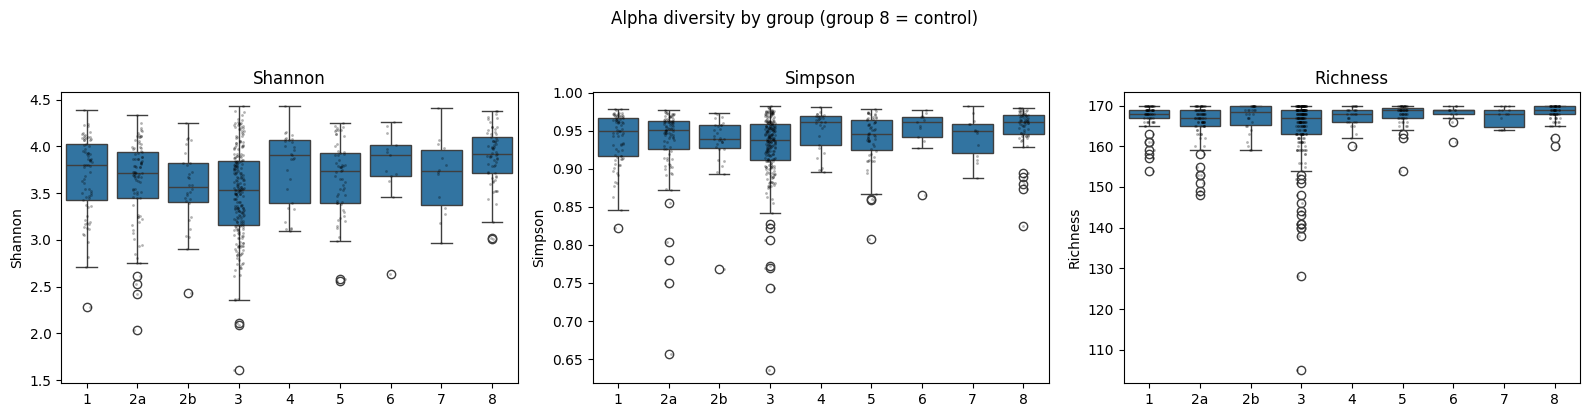

metric,Richness,Shannon,Simpson
group,,,
1,0.356182,7.394319e-03,1.746019e-02
2a,0.000964,2.554480e-04,2.546229e-03
2b,0.356182,2.256630e-04,4.969404e-04
3,0.000029,3.196406e-09,4.032007e-07
4,0.247082,3.166429e-01,6.673995e-01
5,0.521456,1.859326e-03,2.546229e-03
6,0.924203,5.213446e-01,6.673995e-01
7,0.356182,6.924847e-02,8.722949e-02


In [13]:
# --- 12.1 Alpha diversity (within-sample richness/evenness) vs control --------
def shannon(p):
    p = p[p > 0]
    return float(-(p * np.log(p)).sum())


alpha = pd.DataFrame({
    "Shannon":  abund.apply(shannon, axis=1),
    "Simpson":  1 - (abund ** 2).sum(axis=1),
    "Richness": (abund > 0).sum(axis=1),
})
alpha["group"] = groups

# Global Kruskal-Wallis across the nine groups
print("Kruskal-Wallis across all groups:")
for metric in ["Shannon", "Simpson", "Richness"]:
    H, p = kruskal(*[alpha.loc[groups == g, metric] for g in GROUP_ORDER])
    print(f"  {metric:9s} H={H:7.2f}  p={p:.2e}")

# Each disease group vs control (Mann-Whitney U, BH-corrected within each metric)
rows = []
for metric in ["Shannon", "Simpson", "Richness"]:
    ps, recs = [], []
    ctrl = alpha.loc[groups == CONTROL, metric]
    for g in DISEASE:
        a = alpha.loc[groups == g, metric]
        U, p = mannwhitneyu(a, ctrl, alternative="two-sided")
        recs.append((g, a.median(), ctrl.median())); ps.append(p)
    for (g, md, mc), q in zip(recs, false_discovery_control(ps)):
        rows.append(dict(metric=metric, group=g, median_disease=round(md, 4),
                         median_control=round(mc, 4), fdr=q))
alpha_res = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ["Shannon", "Simpson", "Richness"]):
    sns.boxplot(data=alpha, x="group", y=metric, order=GROUP_ORDER, ax=ax)
    sns.stripplot(data=alpha, x="group", y=metric, order=GROUP_ORDER, ax=ax,
                  color="k", size=2, alpha=0.3)
    ax.set_title(metric); ax.set_xlabel("")
fig.suptitle("Alpha diversity by group (group 8 = control)", y=1.03)
fig.tight_layout(); plt.show()

# FDR of each disease group vs control, one column per metric
alpha_res.pivot(index="group", columns="metric", values="fdr").reindex(DISEASE)

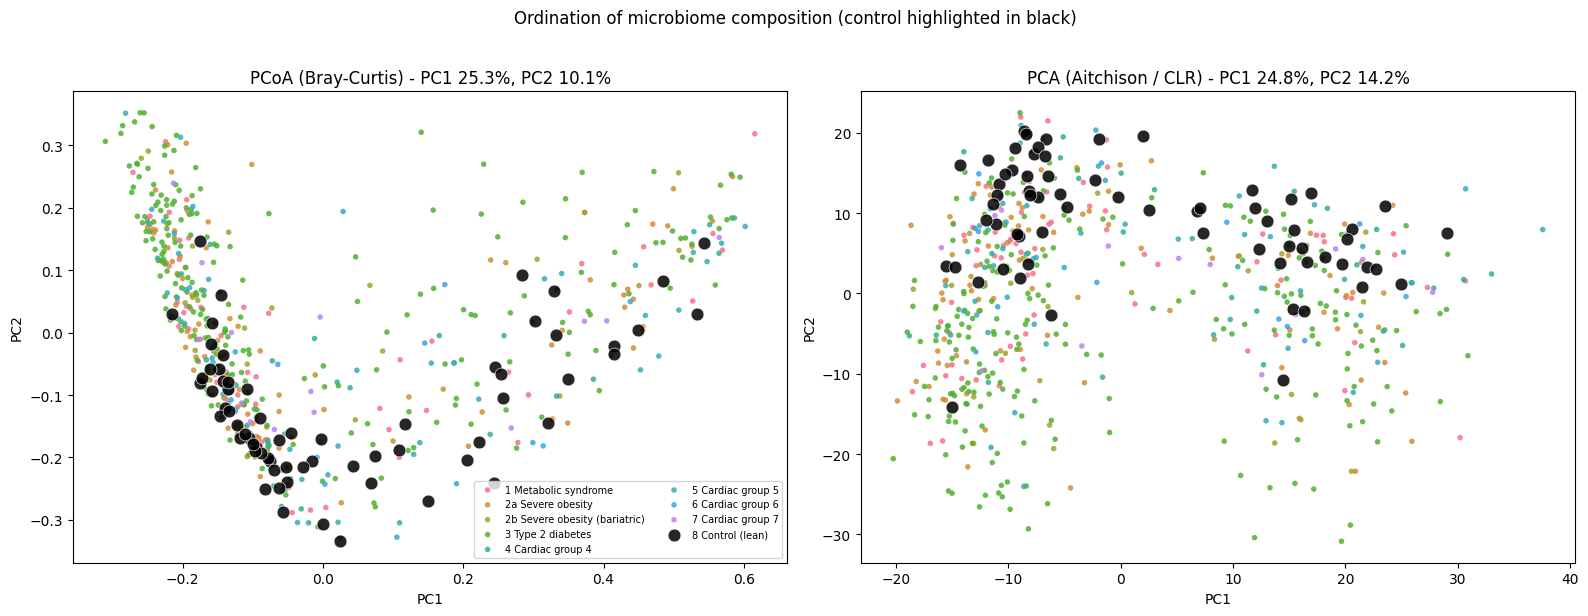

In [14]:
# --- 12.2 Beta diversity & ordination (overall composition) -------------------
# Bray-Curtis on relative abundances, Aitchison (= Euclidean on CLR) for the
# compositional view. PCoA visualises Bray-Curtis, PCA visualises the CLR space.
sample_ids = list(abund.index.astype(str))
dm_bc = DistanceMatrix(squareform(pdist(abund.to_numpy(), metric="braycurtis")), sample_ids)
dm_ait = DistanceMatrix(squareform(pdist(clr.to_numpy(), metric="euclidean")), sample_ids)

pcoa_bc = pcoa(dm_bc, number_of_dimensions=2)
coords_bc = pcoa_bc.samples.iloc[:, :2].to_numpy()
ve_bc = pcoa_bc.proportion_explained.iloc[:2].to_numpy() * 100

pca = PCA(n_components=2, random_state=0).fit(clr.to_numpy())
coords_pca = pca.transform(clr.to_numpy())
ve_pca = pca.explained_variance_ratio_[:2] * 100

g_arr = groups.to_numpy()
palette = dict(zip(GROUP_ORDER, sns.color_palette("husl", len(GROUP_ORDER))))
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for g in GROUP_ORDER:
    m = g_arr == g
    is_ctrl = g == CONTROL
    for ax, coords in [(axes[0], coords_bc), (axes[1], coords_pca)]:
        ax.scatter(coords[m, 0], coords[m, 1],
                   s=85 if is_ctrl else 16, alpha=0.85,
                   color="black" if is_ctrl else palette[g],
                   edgecolor="white" if is_ctrl else "none", linewidth=0.5,
                   label=(f"{g} {GROUP_LABELS[g]}" if ax is axes[0] else None))
axes[0].set_title(f"PCoA (Bray-Curtis) - PC1 {ve_bc[0]:.1f}%, PC2 {ve_bc[1]:.1f}%")
axes[1].set_title(f"PCA (Aitchison / CLR) - PC1 {ve_pca[0]:.1f}%, PC2 {ve_pca[1]:.1f}%")
for ax in axes:
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
axes[0].legend(fontsize=7, ncol=2, loc="best")
fig.suptitle("Ordination of microbiome composition (control highlighted in black)", y=1.02)
fig.tight_layout(); plt.show()

In [15]:
# --- 12.3 PERMANOVA (centroid shift) + PERMDISP (dispersion) ------------------
def _permanova_r2(F, n, a):
    """Recover R^2 from the pseudo-F statistic and the design degrees of freedom."""
    return (F * (a - 1)) / (F * (a - 1) + (n - a))


def run_permanova(dm, grouping, perms=999):
    r = permanova(dm, grouping, permutations=perms)
    F = r["test statistic"]
    return F, _permanova_r2(F, int(r["sample size"]), int(r["number of groups"])), r["p-value"]


print("GLOBAL PERMANOVA (all 9 groups):")
for name, dm in [("Bray-Curtis", dm_bc), ("Aitchison", dm_ait)]:
    F, r2, p = run_permanova(dm, g_arr)
    print(f"  {name:12s} pseudo-F={F:5.2f}  R2={r2:.3f}  p={p:.3f}")

# PERMDISP guards interpretation: a significant PERMANOVA can be driven by
# different group spreads (dispersion) rather than different centroids.
disp = permdisp(dm_bc, g_arr, permutations=999)
print(f"\nPERMDISP (dispersion homogeneity, Bray-Curtis): "
      f"F={disp['test statistic']:.2f}  p={disp['p-value']:.3f}")

# Pairwise: each disease group vs control (BH across the 8 contrasts)
rows, ps = [], []
for g in DISEASE:
    sel = np.isin(g_arr, [g, CONTROL])
    sub_dm = dm_bc.filter([i for i, s in zip(sample_ids, sel) if s])
    F, r2, p = run_permanova(sub_dm, groups[sel].to_numpy())
    rows.append(dict(group=g, label=GROUP_LABELS[g], n=int((g_arr == g).sum()),
                     pseudo_F=round(F, 2), R2=round(r2, 3), p=p)); ps.append(p)
permanova_pw = pd.DataFrame(rows)
permanova_pw["fdr"] = false_discovery_control(ps)
print("\nPairwise PERMANOVA vs control (Bray-Curtis):")
permanova_pw

GLOBAL PERMANOVA (all 9 groups):
  Bray-Curtis  pseudo-F= 2.52  R2=0.033  p=0.001
  Aitchison    pseudo-F= 3.53  R2=0.045  p=0.001

PERMDISP (dispersion homogeneity, Bray-Curtis): F=2.89  p=0.004

Pairwise PERMANOVA vs control (Bray-Curtis):


,group,label,n,pseudo_F,R2,p,fdr
0,1,Metabolic syndrome,73,3.35,0.024,0.002,0.004000
1,2a,Severe obesity,90,4.38,0.028,0.001,0.002667
2,2b,Severe obesity (bariatric),30,5.35,0.054,0.001,0.002667
3,3,Type 2 diabetes,230,9.68,0.032,0.001,0.002667
4,4,Cardiac group 4,29,1.21,0.013,0.224,0.224000
5,5,Cardiac group 5,59,2.41,0.019,0.018,0.028800
6,6,Cardiac group 6,13,1.56,0.020,0.082,0.109333
7,7,Cardiac group 7,14,1.45,0.018,0.100,0.114286


# Differentially abundant taxa per disease group vs control 

In [16]:
# --- 12.4 Per-taxon differential abundance (CLR + Mann-Whitney + BH FDR) -------
# For every disease group vs control, test each taxon on its CLR values and
# attach effect sizes: rank-biserial correlation, CLR mean difference, and the
# log2 fold-change of mean relative abundance (sign: + = enriched in disease).
_eps = abund_f.to_numpy()[abund_f.to_numpy() > 0].min() / 2
da_results = {}
for g in DISEASE:
    d_idx, c_idx = groups == g, groups == CONTROL
    n1, n2 = int(d_idx.sum()), int(c_idx.sum())
    recs = []
    for taxon in taxa_keep:
        a = clr.loc[d_idx, taxon].to_numpy()
        b = clr.loc[c_idx, taxon].to_numpy()
        U, p = mannwhitneyu(a, b, alternative="two-sided")
        rbc = 2 * U / (n1 * n2) - 1            # rank-biserial, sign matches disease - control
        l2fc = np.log2((abund_f.loc[d_idx, taxon].mean() + _eps) /
                       (abund_f.loc[c_idx, taxon].mean() + _eps))
        recs.append((taxon, p, rbc, a.mean() - b.mean(), l2fc))
    d = pd.DataFrame(recs, columns=["taxon", "p", "rank_biserial",
                                    "clr_diff", "log2fc"]).set_index("taxon")
    d["fdr"] = false_discovery_control(d["p"].to_numpy())
    da_results[g] = d

da_summary = pd.DataFrame({
    "n": [int((groups == g).sum()) for g in DISEASE],
    "n_sig_FDR<0.05": [int((da_results[g]["fdr"] < 0.05).sum()) for g in DISEASE],
    "n_enriched": [int(((da_results[g]["fdr"] < 0.05) & (da_results[g]["clr_diff"] > 0)).sum())
                   for g in DISEASE],
    "n_depleted": [int(((da_results[g]["fdr"] < 0.05) & (da_results[g]["clr_diff"] < 0)).sum())
                   for g in DISEASE],
}, index=DISEASE)
da_summary.index.name = "group"
print("Differentially abundant taxa per disease group vs control (FDR < 0.05):")
da_summary

Differentially abundant taxa per disease group vs control (FDR < 0.05):


,n,n_sig_FDR<0.05,n_enriched,n_depleted
group,,,,
1,73,41,26,15
2a,90,78,49,29
2b,30,63,32,31
3,230,97,51,46
4,29,0,0,0
5,59,17,5,12
6,13,1,1,0
7,14,0,0,0


In [17]:
# --- 12.4b Top enriched / depleted taxa for a given disease group -------------
def top_taxa(group, k=8):
    d = da_results[group].sort_values("clr_diff")
    out = pd.concat([d.head(k), d.tail(k)])
    return out[["clr_diff", "log2fc", "rank_biserial", "fdr"]].round(3)


# Type 2 diabetes (group 3) is the best-powered contrast (n=230 vs 66 control)
print("Group 3 (Type 2 diabetes): most depleted (top) and most enriched (bottom) taxa")
top_taxa("3", k=8)

Group 3 (Type 2 diabetes): most depleted (top) and most enriched (bottom) taxa


,clr_diff,log2fc,rank_biserial,fdr
taxon,,,,
CAG-115 sp003531585,-4.385,-3.196,-0.694,0.0
UBA11524 sp000437595,-3.933,-2.730,-0.603,0.0
CAG-83 sp000435555,-3.235,-1.822,-0.593,0.0
PeH17 sp000435055,-2.929,-1.556,-0.535,0.0
CAG-170 sp002404795,-2.766,-2.078,-0.602,0.0
Faecousia sp000434635,-2.373,-2.038,-0.577,0.0
Eubacterium_F sp003491505,-2.266,-1.892,-0.546,0.0
Angelakisella sp900547385,-2.211,-1.341,-0.477,0.0
Bacteroides sp902362375,1.381,1.058,0.438,0.0


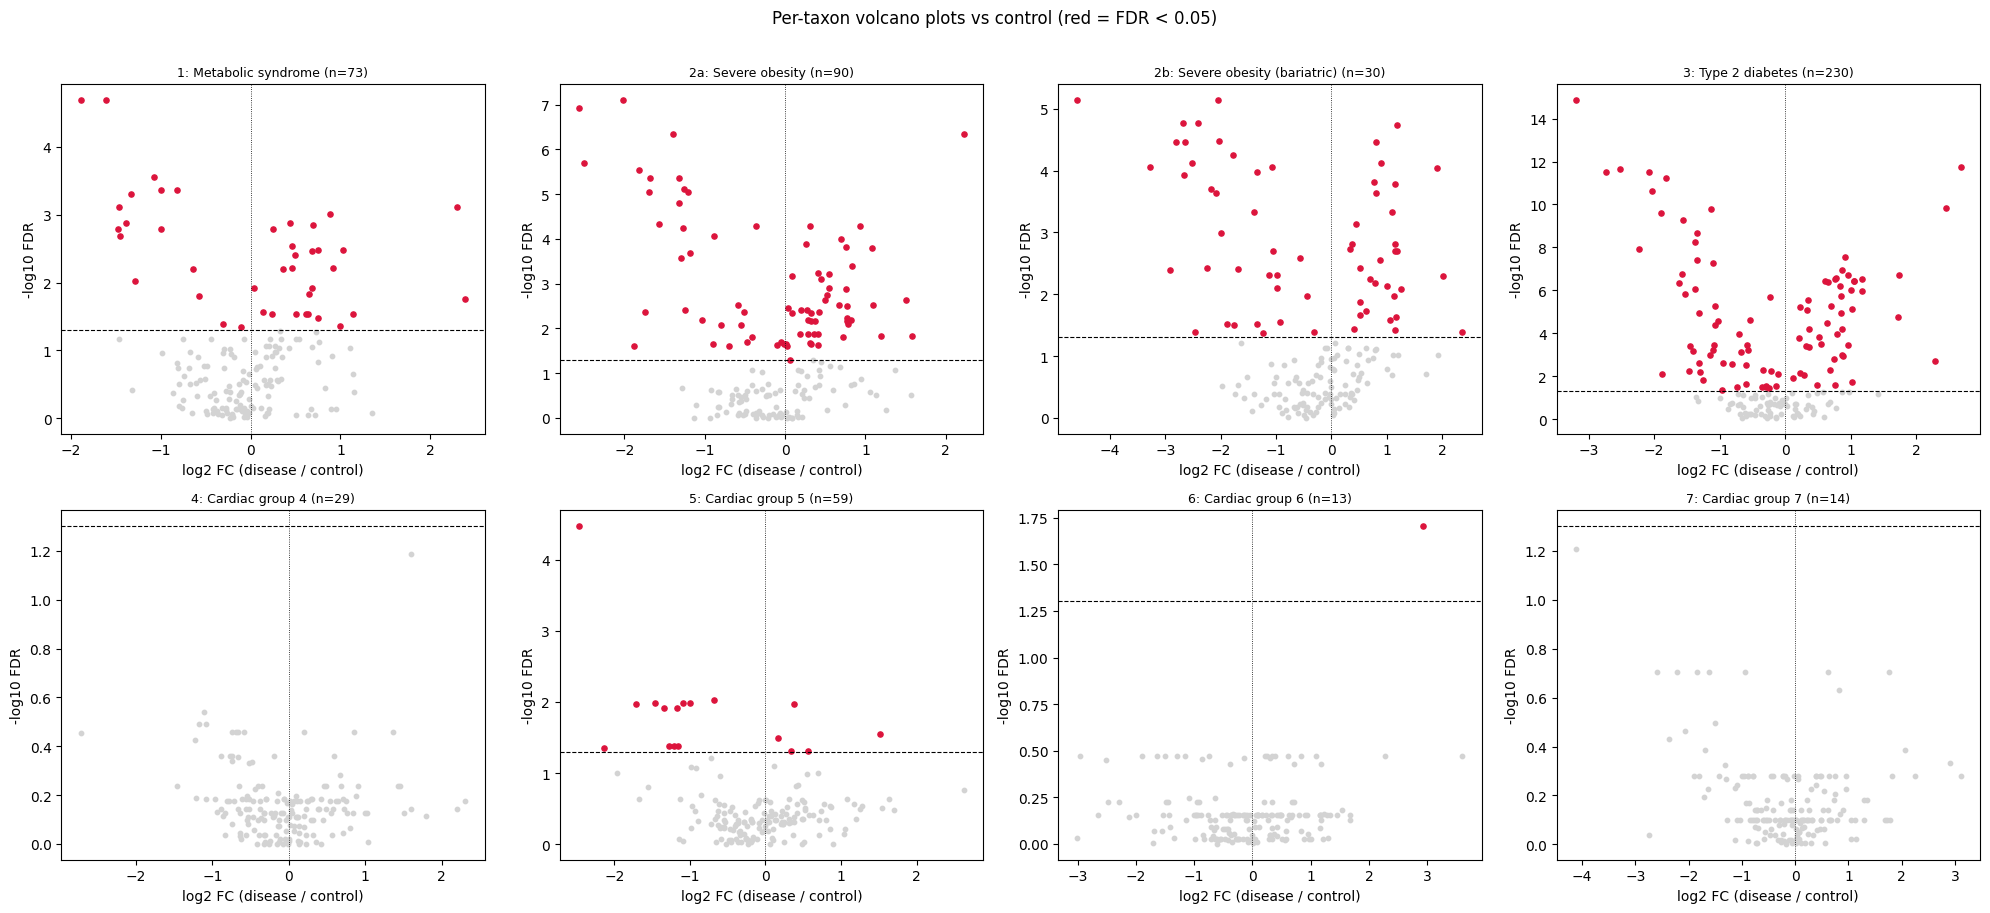

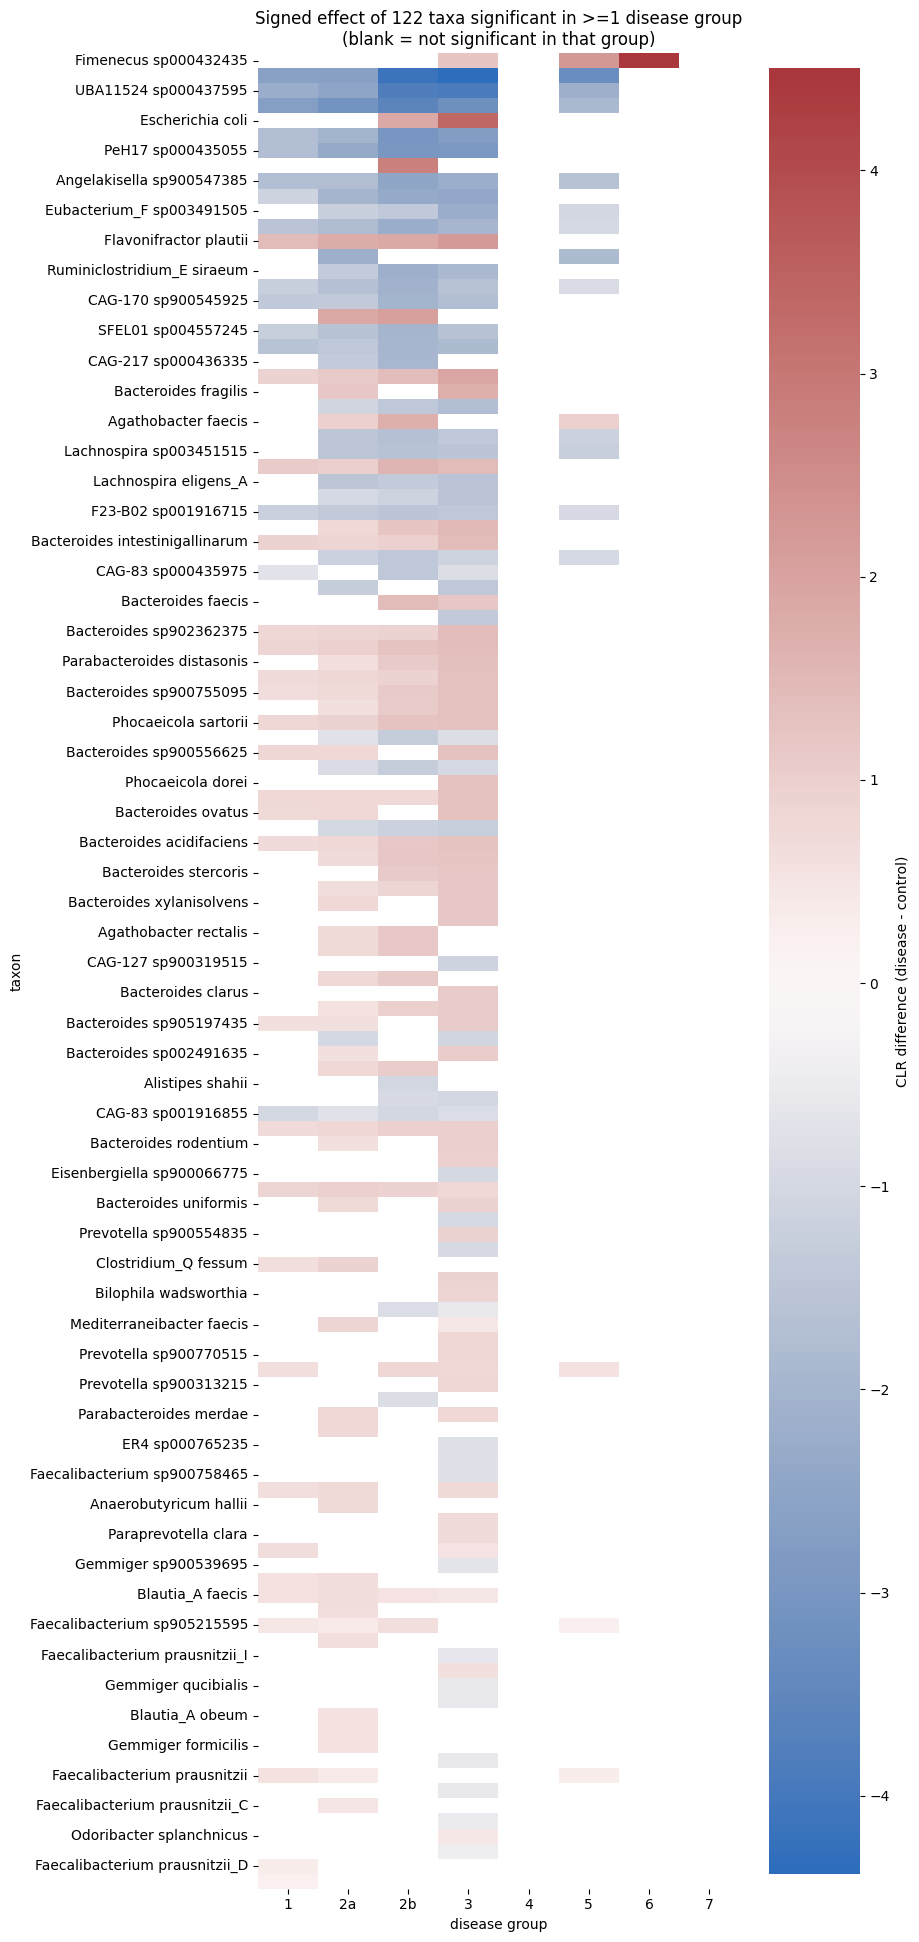

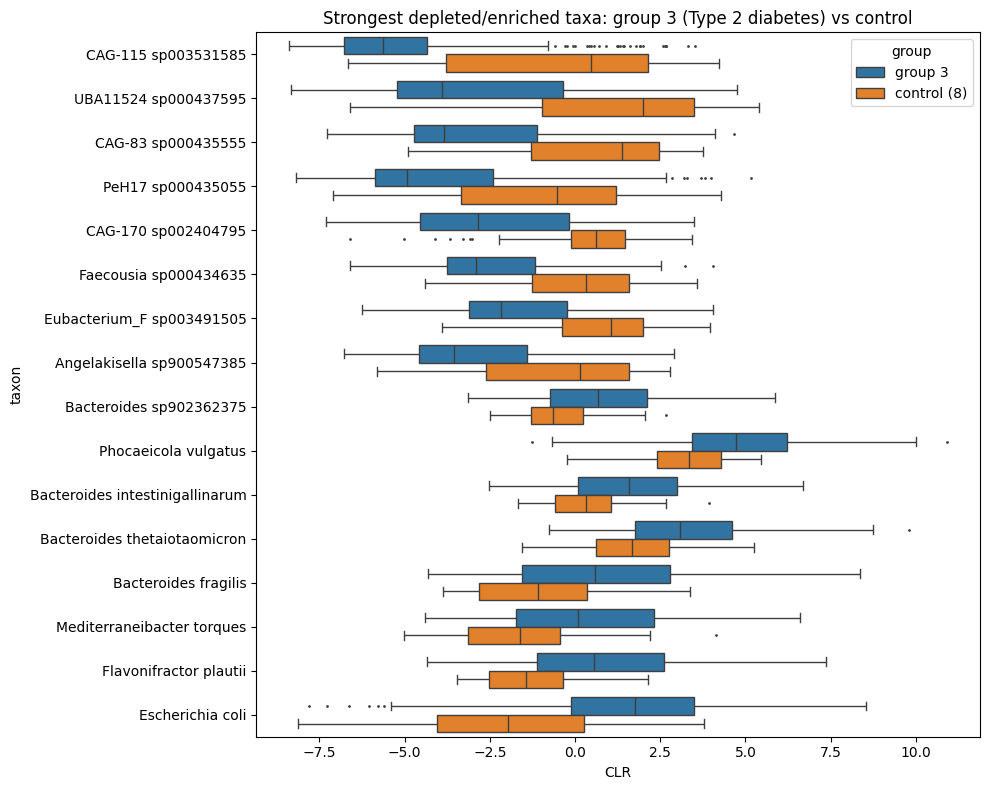

In [18]:
# --- 12.5 Visualising the disease-specific signatures -------------------------
# (a) Volcano plot per disease group: log2 FC vs -log10 FDR (red = FDR < 0.05)
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, g in zip(axes.ravel(), DISEASE):
    d = da_results[g]
    sig = d["fdr"] < 0.05
    ax.scatter(d.loc[~sig, "log2fc"], -np.log10(d.loc[~sig, "fdr"]),
               s=10, color="lightgrey")
    ax.scatter(d.loc[sig, "log2fc"], -np.log10(d.loc[sig, "fdr"]),
               s=14, color="crimson")
    ax.axhline(-np.log10(0.05), ls="--", lw=0.8, color="k")
    ax.axvline(0, ls=":", lw=0.6, color="k")
    ax.set_title(f"{g}: {GROUP_LABELS[g]} (n={int((groups == g).sum())})", fontsize=9)
    ax.set_xlabel("log2 FC (disease / control)"); ax.set_ylabel("-log10 FDR")
fig.suptitle("Per-taxon volcano plots vs control (red = FDR < 0.05)", y=1.01)
fig.tight_layout(); plt.show()

# (b) Heatmap: signed CLR difference for taxa significant in >=1 disease group
sig_union = sorted({t for d in da_results.values() for t in d.index[d["fdr"] < 0.05]})
hm = pd.DataFrame({g: da_results[g]["clr_diff"].where(da_results[g]["fdr"] < 0.05)
                   for g in DISEASE}).loc[sig_union]
hm = hm.loc[hm.abs().max(axis=1).sort_values(ascending=False).index]   # strongest signals on top
fig, ax = plt.subplots(figsize=(9, max(5, len(sig_union) * 0.16)))
sns.heatmap(hm, cmap="vlag", center=0, ax=ax,
            cbar_kws={"label": "CLR difference (disease - control)"})
ax.set_title(f"Signed effect of {len(sig_union)} taxa significant in >=1 disease group\n"
             "(blank = not significant in that group)")
ax.set_xlabel("disease group"); fig.tight_layout(); plt.show()

# (c) Boxplots of the strongest taxa for Type 2 diabetes (group 3) vs control
g = "3"
focus = top_taxa(g, k=8).index
sub = clr.loc[groups.isin([g, CONTROL]), focus].copy()
sub["group"] = np.where(groups[sub.index].to_numpy() == CONTROL, "control (8)", f"group {g}")
melt = sub.melt(id_vars="group", var_name="taxon", value_name="CLR")
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=melt, y="taxon", x="CLR", hue="group", ax=ax, fliersize=1)
ax.set_title(f"Strongest depleted/enriched taxa: group {g} ({GROUP_LABELS[g]}) vs control")
fig.tight_layout(); plt.show()

Global cohort (all centers) n = 1390


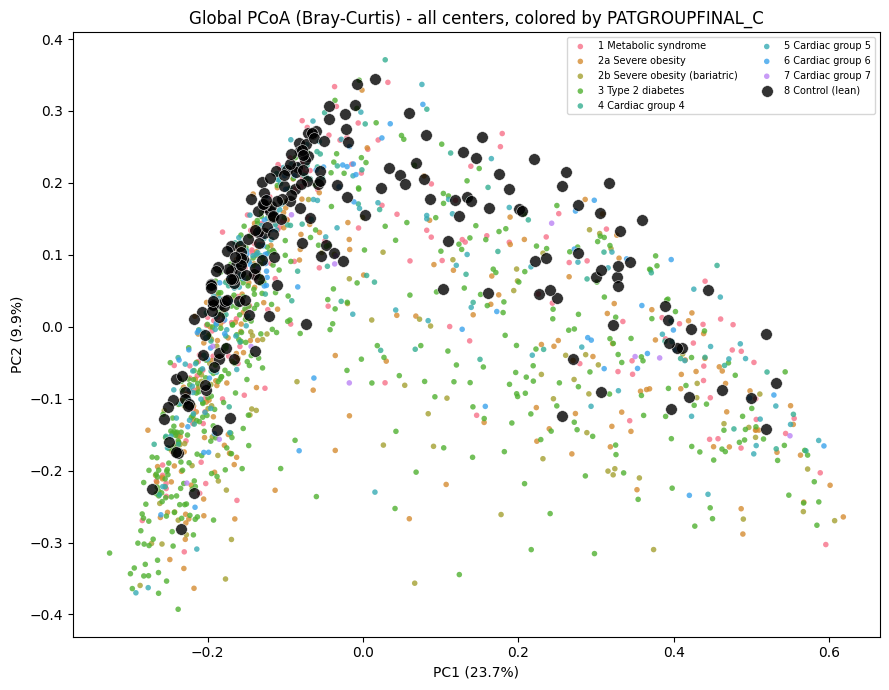

,n
PATGROUPFINAL_C,
1,177
2a,192
2b,102
3,425
4,80
5,122
6,74
7,14
8,204


In [19]:
# --- 13.1 Global cohort (all centers) + global PCoA ---------------------------
global_micro = _micro.dropna(how="all")
global_abund = global_micro.astype(float)
global_abund = global_abund.div(global_abund.sum(axis=1), axis=0)   # re-close to sum 1
global_groups = _meta["PATGROUPFINAL_C"].astype(str).reindex(global_abund.index)
_valid = global_groups.notna() & (global_groups != "nan")
global_abund, global_groups = global_abund.loc[_valid], global_groups.loc[_valid]
print(f"Global cohort (all centers) n = {len(global_abund)}")

global_bc = squareform(pdist(global_abund.to_numpy(), metric="braycurtis"))
global_ids = list(global_abund.index.astype(str))
global_ord = pcoa(DistanceMatrix(global_bc, global_ids), number_of_dimensions=2)
gcoords = global_ord.samples.iloc[:, :2].to_numpy()
gve = global_ord.proportion_explained.iloc[:2].to_numpy() * 100

gg_arr = global_groups.to_numpy()
fig, ax = plt.subplots(figsize=(9, 7))
for g in GROUP_ORDER:
    m = gg_arr == g
    is_ctrl = g == CONTROL
    ax.scatter(gcoords[m, 0], gcoords[m, 1],
               s=70 if is_ctrl else 16, alpha=0.8,
               color="black" if is_ctrl else palette[g],
               edgecolor="white" if is_ctrl else "none", linewidth=0.4,
               label=f"{g} {GROUP_LABELS[g]}")
ax.set_xlabel(f"PC1 ({gve[0]:.1f}%)"); ax.set_ylabel(f"PC2 ({gve[1]:.1f}%)")
ax.set_title("Global PCoA (Bray-Curtis) - all centers, colored by PATGROUPFINAL_C")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout(); plt.show()

global_groups.value_counts().reindex(GROUP_ORDER).rename("n").to_frame()

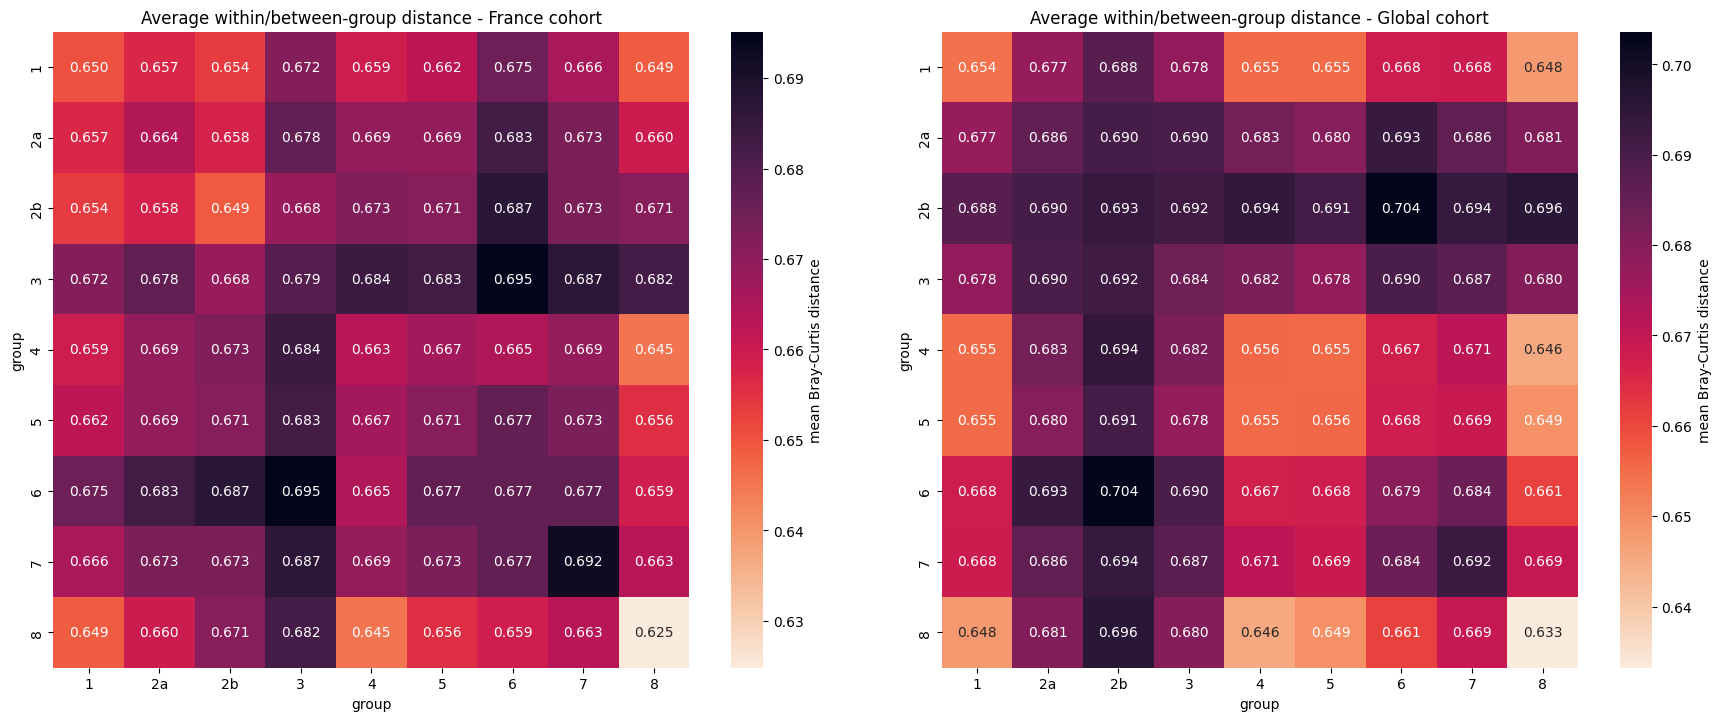

Average within/between-group Bray-Curtis distance (France cohort):


,1,2a,2b,3,4,5,6,7,8
1,0.650,0.657,0.654,0.672,0.659,0.662,0.675,0.666,0.649
2a,0.657,0.664,0.658,0.678,0.669,0.669,0.683,0.673,0.660
2b,0.654,0.658,0.649,0.668,0.673,0.671,0.687,0.673,0.671
3,0.672,0.678,0.668,0.679,0.684,0.683,0.695,0.687,0.682
4,0.659,0.669,0.673,0.684,0.663,0.667,0.665,0.669,0.645
5,0.662,0.669,0.671,0.683,0.667,0.671,0.677,0.673,0.656
6,0.675,0.683,0.687,0.695,0.665,0.677,0.677,0.677,0.659
7,0.666,0.673,0.673,0.687,0.669,0.673,0.677,0.692,0.663
8,0.649,0.660,0.671,0.682,0.645,0.656,0.659,0.663,0.625


In [20]:
# --- 13.2 Average within/between-group distance: France vs global -------------
def avg_group_distances(dist_sq, labels, order=GROUP_ORDER):
    """Mean within-group (diagonal, self-distances excluded) and between-group
    (off-diagonal) distance. `dist_sq` is an n x n square distance matrix and
    `labels` a Series aligned by position to its rows; rows/cols follow `order`.
    """
    D = np.asarray(dist_sq, dtype=float)
    lab = pd.Series(labels).reset_index(drop=True).to_numpy()
    present = [g for g in order if (lab == g).any()]
    out = pd.DataFrame(index=present, columns=present, dtype=float)
    for gi in present:
        ii = np.where(lab == gi)[0]
        for gj in present:
            jj = np.where(lab == gj)[0]
            block = D[np.ix_(ii, jj)]
            if gi == gj:
                mask = ~np.eye(len(ii), dtype=bool)
                out.loc[gi, gj] = block[mask].mean() if len(ii) > 1 else np.nan
            else:
                out.loc[gi, gj] = block.mean()
    return out


france_avg_dist = avg_group_distances(dm_bc.data, groups)     # reuse France Bray-Curtis
global_avg_dist = avg_group_distances(global_bc, global_groups)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (title, tbl) in zip(axes, [("France cohort", france_avg_dist),
                                   ("Global cohort", global_avg_dist)]):
    sns.heatmap(tbl.astype(float), annot=True, fmt=".3f", cmap="rocket_r",
                square=True, ax=ax, cbar_kws={"label": "mean Bray-Curtis distance"})
    ax.set_title(f"Average within/between-group distance - {title}")
    ax.set_xlabel("group"); ax.set_ylabel("group")
fig.tight_layout(); plt.show()

print("Average within/between-group Bray-Curtis distance (France cohort):")
france_avg_dist.astype(float).round(3)